<img src='https://github.com/wekeo/ai4EM_MOOC/raw/04147f290cfdcce341f819eab7ad037b95f25600/img/ai4eo_logos.jpg' alt='Logo EU Copernicus WEkEO' align='center' width='100%'></img>


# WEKEO TRAINING

<div style="text-align: right"><i>  </i></div>

***
<center><h1> Natural Disasters: Wildfires monitoring in Spain</h1></center>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Run" and select "Run All Above Selected Cell".<br>

**General Note 3**: To explore more (Python and R) content, there is our [**Jupyter Catalogue**](https://notebooks.apps.mercator.dpi.wekeo.eu/), and if you seek support, there are plenty of useful resources in our [**Help Center**](https://help.wekeo.eu/en/). Feel free to contact us using our [**live chat widget**](https://www.wekeo.eu/support) or asynchronously at [support@wekeo.eu](support@wekeo.eu) ! <br>

***

# Table of contents
1. [Introduction](#1.-Introduction)  
2. [Setting up the Python environment](#2.-Setting-up-the-Python-environment)  
   - [2.1 Required Python modules](#2.1-Required-Python-modules)  
3. [Data Access](#3.-Data-Access)  
   - [3.1 Presentation of the products used](#3.1-Presentation-of-the-products-used)  
   - [3.2 Retrieving the data with HDA API](#3.2-Retrieving-the-Data)
4. [Data loading and visualization](#4.load_visualize)
    - [Load Sentinel-3 SLSTR NRT FRP data](#4.1-load_s3_frp)
    - [Load, mask and regrid NRT FRP computed from MWIR channel (3.7 um)](#4.2-.load_mwir)
    - [Load Sentinel-3 SLSTR NRT AOD data](#4.3-.load_s3_AOD)
    - [Visualize Sentinel-3 SLSTR NRT data](#4.4-.visualize) 
5. [Conclusion](#7.-Conclusion)  


# 1. Introduction

[Go back to the "Table of contents"](#Table-of-contents)

As a case study, this notebook explores the Iberian Pennisula wildfires from 15 to 17 August 2025.

Southern Europe is highly susceptible to large wildfires, which can have severe socio-economic and ecological consequences. The Mediterranean climate, characterized by hot, dry summers and mild, wet winters, creates favorable conditions for the outbreak and rapid spread of fires, exacerbated by factors such as drought, high temperatures, and strong winds. Therefore, a reliable detection of fires as well as an estimation of their severity and impact is of great importance when addressing the risk posed by wildfires.


# 2. Setting up the Python environment
[Go back to the "Table of contents"](#Table-of-contents)

## 2.1 Required Python modules
[Go back to the "Table of contents"](#Table-of-contents)

The Jupyter Notebook must be set up with all the necessary available tools from the Jupyter Notebook ecosystem. Here is the list of the modules we will be using in this exercise. They are pre-installed in the *wekeolab* kernel, which we recommend using.

| Module name | Description |
| :---: | :---|
| **numpy** | [NumPy](https://numpy.org/) is the fundamental package for scientific computing with Python and for managing ND-arrays. |
| **xarray** | [Xarray](http://xarray.pydata.org/en/stable/) is a very user friendly library for manipulating NetCDF files within Python. It introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays, which allows for a more intuitive, more concise, and less error-prone developer experience. |
| **matplotlib** |[Matplotlib](https://matplotlib.org/) is a Python 2D plotting library which produces high quality figures. |
| **cartopy** |[Cartopy](https://scitools.org.uk/cartopy/docs/latest/) is a library for plotting maps and geospatial data analyses in Python. |

In [1]:
# Modules system
import warnings
warnings.filterwarnings('ignore')
import getpass
import os
from pathlib import Path

import zipfile

# Modules related to data retrieving
from hda import Client
import json

# Modules related to plot and EO data manipulation
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.animation as animation
import matplotlib.dates as mdates

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [2]:
# util functions

from helper_functions import *

# 3. Data Access

[Go back to the "Table of contents"](#Table-of-contents)


## 3.1. Presentation of the products used

[Go back to the "Table of contents"](#Table-of-contents)


From the WEkEO [Data Viewer](https://www.wekeo.eu/data?view=viewer), you can explore all the products available with many filters to select the region you are interested in, the parameters you want to study, etc.

This notebook will make use of **Sentinel-3** data. We describe below the datasets retrieved from WEkEO.

We are going to use [Copernicus Sentinel-3 SLSTR Near-Real-Time Fire Radiative Power (FRP)](https://wekeo.copernicus.eu/data?view=dataset&dataset=EO:EUM:DAT:SENTINEL-3:0417) product identifies the location and quantifies the radiative power of any hotspot present on land and ocean, that radiates a heating signal within a pixel size of 1 km<sup>2</sup>.

All threatening hotspots are identified and characterised within three hours from SLSTR observation sensing time.
The current version of the Near-Real-Time (NRT) S3 FRP processor (Collection 3 available since 4 July 2024) is applicable day and night (over land), and night (over waters for offshore gas flares). The NRT S3 FRP product is pre-operational after having reached lately a high level of quality and maturity, a comprehensive global validation, and positive feedback by experts and users.

---------------------

The [Level 2 (L2) Copernicus Sentinel-3 Near Real Time (NRT) Aerosol Optical Depth (AOD)](https://wekeo.copernicus.eu/data?view=dataset&dataset=EO:EUM:DAT:SENTINEL-3:0416) product quantifies the abundance of aerosol particles, and monitors their global distribution and long-range transport, at the scale of 9.5 x 9.5 km2. All observations are made available in less than 3 hours from the SLSTR observation sensing time. It is only applicable during daytime.

The product is generated from the reference ‘Optimized Simultaneous Surface Aerosol Retrieval for Copernicus Sentinel-3' (OSSAR-CS3) processor, dedicated to processing SLSTR data, and procured by EUMETSAT on behalf of the European Commission.

*Global coverage is achieved with ~daily observations when combining Sentinel-3A and Sentinel-3B, while each satellite individually provides full coverage approximately every 2 days.*

We show below a table summarizing the main characteristics of the products retrieved from WEKEO.

| Mission and sensor   | Variable used | Product Identifier | Product Navigator | Temporal resolution | Spatial resolution | Temporal coverage |
|:--------------------:|:-----------------------:|:-----------------:|:--------------------:|:-----------------------:|:-----------------:|:-----------------:|
|  Sentinel-3 SLSTR | Level 2 Fire Radiative Power in NRT | EO:EUM:DAT:SENTINEL-3:0417 | [link](https://wekeo.copernicus.eu/data?view=dataset&dataset=EO:EUM:DAT:SENTINEL-3:0417) | two times per day | 1 x 1 km2 | April 8, 2020 to now|
|  Sentinel-3 SLSTR | Level 2 Aerosol Optical Depth in NRT  | EO:EUM:DAT:SENTINEL-3:0416 |[link](https://wekeo.copernicus.eu/data?view=dataset&dataset=EO:EUM:DAT:SENTINEL-3:0416) |  two times per day | 9.5 x 9.5 km2 |August 19, 2020 to now|




## 3.2. Retrieving the data

[Go back to the "Table of contents"](#Table-of-contents)

There are many ways to [download data in WEkEO](https://help.wekeo.eu/en/articles/6416936-how-to-download-wekeo-data). You can do it manually from the [Data Viewer](https://www.wekeo.eu/data?view=viewer), but here we will download data through Python, using the Harmonized Data Access (HDA) API provided by WEkEO. The HDA client provides a fully compliant Python3 client that can be used to search and download products using the Harmonized Data Access WEkEO API.

### 3.2.1 HDA API

[Go back to the "Table of contents"](#Table-of-contents)

In this section we show how to use the **HDA API**, which will work with most WEkEO datasets.


First you need to make sure you have a `.hdarc` saved in your root directory. Follow the method described [here](https://help.wekeo.eu/en/articles/6751608-how-to-use-the-hda-api-in-python#h_e1d774cae9). 

📌 **Note**: For the sake of convenience, you can run the following cell to generate it automatically:

In [3]:
# Default location expected by hda package
hdarc = Path(Path.home() / '.hdarc')

# Create it only if it does not already exists
if not hdarc.is_file():
    USERNAME = input('Enter your username: ')
    PASSWORD = getpass.getpass('Enter your password: ')

    with open(Path.home() / '.hdarc', 'w') as f:
        f.write(f'user:{USERNAME}\n')
        f.write(f'password:{PASSWORD}\n')

hda_client = Client()

Once the necessary configuration for the access credentials is set, it is required to define a request with the configuration of the data to be downloaded. In this dictionary, the data corresponding to various parameters of the requested data must be specified, such as:

* `dataset_id`: The identifier code of the Copernicus product to be accessed.
* `startdate` and `enddate`: The start and end dates for the download.
* `time`: The hourly frequency of the data.
* `variable`: List of variables requested.
* `bbox`: The lat/lon boundaries of the study region.

Since this tutorial proposes the visualization of two different datasets, the following code cell shows a dictionary containing the two requests corresponding to the air quality reanalysis dataset (`S3-FRP`) and the emissions data (`S3-AOD`).

In [7]:
RequestDict = {
    'S3-FRP' :{
          "dataset_id": "EO:EUM:DAT:SENTINEL-3:0417",
          "publication": "2023-04-13T17:37:51.024Z",
          "startdate": "2025-08-16T10:00:00.000Z",
          "enddate": "2025-08-16T10:59:59.999Z",
          "bbox": [
            -10.026525679281129,
            36.328976660214835,
            -2.9684156313263603,
            43.86338403571958
          ],
          "itemsPerPage": 200,
          "startIndex": 0
        },
    
    'S3-AOD' :{
          "dataset_id": "EO:EUM:DAT:SENTINEL-3:0416",
          "publication": "2023-04-13T17:37:51.024Z",
          "startdate": "2025-08-16T10:00:00.000Z",
          "enddate": "2025-08-16T10:59:59.999Z",
          "bbox": [
            -10.026525679281129,
            36.328976660214835,
            -2.9684156313263603,
            43.86338403571958
          ],
          "itemsPerPage": 200,
          "startIndex": 0
        }
}

In [9]:
Request = RequestDict['S3-FRP']
display(Request)

{'dataset_id': 'EO:EUM:DAT:SENTINEL-3:0417',
 'publication': '2023-04-13T17:37:51.024Z',
 'startdate': '2025-08-16T10:00:00.000Z',
 'enddate': '2025-08-16T10:59:59.999Z',
 'bbox': [-10.026525679281129,
  36.328976660214835,
  -2.9684156313263603,
  43.86338403571958],
 'itemsPerPage': 200,
 'startIndex': 0}

Running the next cell will launch [**the download of the data (more details)**](https://help.wekeo.eu/en/articles/6751608-how-to-use-the-hda-api-in-python#h_605d4bdc05). Depending on the product and request, it may take some time. 

In [5]:
### Retrieve data
## Path to local data storage
output_path = './data'

matches = hda_client.search(Request)

# Print results
print(matches)

SearchResults[items=3,volume=39.4MB]


In [6]:
matches.download(output_path)

 46%|████▋     | 6.19M/13.4M [00:00<00:00, 26.4MB/s]
                                                    
%|▏         | 220k/13.4M [00:00<00:06, 2.22MB/s]
%|██        | 2.85M/13.4M [00:00<00:00, 17.0MB/s]
%|███████▏  | 9.69M/13.4M [00:00<00:00, 41.8MB/s]
                                                    

The same thing we do with the other dataset.

In [10]:
Request = RequestDict['S3-AOD']
display(Request)

output_path = './data'

matches = hda_client.search(Request)

# Print results
print(matches)

matches.download(output_path)

{'dataset_id': 'EO:EUM:DAT:SENTINEL-3:0416',
 'publication': '2023-04-13T17:37:51.024Z',
 'startdate': '2025-08-16T10:00:00.000Z',
 'enddate': '2025-08-16T10:59:59.999Z',
 'bbox': [-10.026525679281129,
  36.328976660214835,
  -2.9684156313263603,
  43.86338403571958],
 'itemsPerPage': 200,
 'startIndex': 0}

SearchResults[items=3,volume=4MB]



%|          | 0.00/1.49M [00:00<?, ?B/s]
  0%|          | 0.00/1.22M [00:00<?, ?B/s].51MB/s]
                                                   
%|          | 0.00/1.42M [00:00<?, ?B/s]
                                        

📌 **Note**: After downloading the data, you may need to **unzip** it using a terminal in order to access the files.

In [11]:
for file_name in os.listdir(output_path):
    if file_name.lower().endswith(".zip"):
        zip_path = os.path.join(output_path, file_name)
        extract_folder = os.path.join(output_path, os.path.splitext(file_name)[0])
        
        # Create output folder if it doesn't exist
        os.makedirs(extract_folder, exist_ok=True)
        
        # Extract the zip file
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_folder)
        
        print(f"Extracted: {file_name} → {extract_folder}")

Extracted: S3A_SL_2_AOD____20250816T105652_20250816T110152_20250816T130000_0299_129_208______MAR_O_NR_003.SEN3.zip → ./data/S3A_SL_2_AOD____20250816T105652_20250816T110152_20250816T130000_0299_129_208______MAR_O_NR_003.SEN3
Extracted: S3B_SL_2_FRP____20250816T101824_20250816T102324_20250816T122038_0299_110_065______MAR_O_NR_003.SEN3.zip → ./data/S3B_SL_2_FRP____20250816T101824_20250816T102324_20250816T122038_0299_110_065______MAR_O_NR_003.SEN3
Extracted: S3B_SL_2_AOD____20250816T101825_20250816T102324_20250816T122129_0299_110_065______MAR_O_NR_003.SEN3.zip → ./data/S3B_SL_2_AOD____20250816T101825_20250816T102324_20250816T122129_0299_110_065______MAR_O_NR_003.SEN3
Extracted: S3B_SL_2_FRP____20250816T102324_20250816T102824_20250816T121934_0299_110_065______MAR_O_NR_003.SEN3.zip → ./data/S3B_SL_2_FRP____20250816T102324_20250816T102824_20250816T121934_0299_110_065______MAR_O_NR_003.SEN3
Extracted: S3A_SL_2_FRP____20250816T105651_20250816T110151_20250816T125916_0299_129_208______MAR_O_NR_00

# 4. Data loading and visualization

[Go back to the "Table of contents"](#Table-of-contents)

### <a id='load_s3_frp'></a> 4.1 - Load Sentinel-3 SLSTR NRT FRP data

Each FRP product is distributed as a **folder** ending with `.SEN3/`.  
Inside, multiple NetCDF files and metadata components are included.

Example product structure:

- **`FRP_MWIR1km_standard.nc`** → Main operational FRP product (1 km, MWIR channel)

- **`FRP_MWIR1km_alternative.nc`** → Alternative MWIR-based FRP retrieval

- **`FRP_Merged_MWIR1kmStandard_SWIR1km.nc`** → Merged MWIR + SWIR FRP product

- **`FRP_SWIR500m.nc`** → High-resolution SWIR-based FRP (500 m)

- **`geodetic_in.nc`** → Geolocation information
  - `latitude`
  - `longitude`
  - pixel corner coordinates

- **CSV equivalents** (`*.csv`) → Tabular versions of the FRP detections

- **`xfdumanifest.xml`** → Manifest file describing metadata and file list  
- **`manifest.xml` / `EOPMetadata.xml`** → Additional metadata files  
- **`browse.jpg`** → Quick-look image

For this training, we will use **`FRP_Merged_MWIR1kmStandard_SWIR1km.nc`**, which contains the operational Fire Radiative Power for both MWIR and SWIR channels along with geolocation and quality information.

The first step is to load the data file with xarray's `xr.open_dataset()` function.

Once the data file is loaded, we see that the data file has three dimensions: `columns`, `fires` and `rows`. The data and additional information, such as quality flags or latitude and longitude information, is stored as data variables.

There are 2 variables of interest:
- `FRP_MWIR` - Fire Radiative Power computed from MWIR channel (3.7 um) [MW]
- `FRP_SWIR` - Fire Radiative Power computed from SWIR channel (2.25 um) [MW]

The channels differ in the type of fire they can detect. The `FRP_MWIR` channel detects hotspots with a temperature lower than 1100 Kelvin (typically wildfires), whereas the `FRP_SWIR` channel detects hotspots with higher temperatures above 1100 Kelvin (intense wildfires and gas flares). Both channels can be processes as shown below, in this notebook we will focus only on `FRP_MWIR`.

FRP products mainly use MWIR during the day due to its reliability, while at night, combining MWIR and SWIR helps detect a wider range of fire intensities. SWIR is not yet used during daytime.

We load one of the files using `xr.open_dataset()` to inspect its content.

In [12]:
# You can change the folder below
data_folder = 'S3A_SL_2_FRP____20250816T105651_20250816T110151_20250816T125916_0299_129_208______MAR_O_NR_003.SEN3'

frp_xr = xr.open_dataset(Path(output_path) / data_folder / data_folder / "FRP_Merged_MWIR1kmStandard_SWIR1km.nc", engine='netcdf4')
frp_xr

<xarray.Dataset> Size: 19kB
Dimensions:                            (merged_MWIR1kmStandard_SWIR1km: 269)
Dimensions without coordinates: merged_MWIR1kmStandard_SWIR1km
Data variables: (12/22)
    i                                  (merged_MWIR1kmStandard_SWIR1km) int16 538B ...
    j                                  (merged_MWIR1kmStandard_SWIR1km) int32 1kB ...
    latitude                           (merged_MWIR1kmStandard_SWIR1km) float32 1kB ...
    longitude                          (merged_MWIR1kmStandard_SWIR1km) float32 1kB ...
    time                               (merged_MWIR1kmStandard_SWIR1km) datetime64[ns] 2kB ...
    FRP_SWIR                           (merged_MWIR1kmStandard_SWIR1km) float32 1kB ...
    ...                                 ...
    confidence_clear_sky_freezing      (merged_MWIR1kmStandard_SWIR1km) int8 269B ...
    confidence_clear_sky_split_window  (merged_MWIR1kmStandard_SWIR1km) int8 269B ...
    solar_zenith                       (merged_MWIR1kmStandard_SWIR1km) float32 1kB ...
    solar_azimuth                      (merged_MWIR1kmStandard_SWIR1km) float32 1kB ...
    sat_zenith                         (merged_MWIR1kmStandard_SWIR1km) float32 1kB ...
    sat_azimuth                        (merged_MWIR1kmStandard_SWIR1km) float32 1kB ...
Attributes: (12/17)
    title:                  SLSTR Level 2 Product, Fire Radiative Power measu...
    comment:                 
    netCDF_version:         4.2 of Jun 13 2024 12:58:03 $
    product_name:           S3A_SL_2_FRP____20250816T105651_20250816T110151_2...
    institution:            MAR
    source:                 IPF-SL-2-FRP 04.03
    ...                     ...
    absolute_orbit_number:  49461
    start_time:             2025-08-16T10:56:51.025225Z
    stop_time:              2025-08-16T11:01:51.011426Z
    processing_baseline:    FRP_NRT.003.01.00
    track_offset:           998
    start_offset:           13894

#### Load `latitude`, `longitude`, `start_time` and `stop_time` information

You can already load the `latitude`, `longitude`, `start_time` and `stop_time` information, which will be required later for the regridding process.

In [13]:
lat_frp = frp_xr['latitude']
lon_frp = frp_xr['longitude']

start_time = frp_xr.start_time
stop_time = frp_xr.stop_time

## <a id='load_mwir'></a>2 - Load, mask and regrid `FRP computed from MWIR channel (3.7 um)`

The first step is to load the `FRP_MWIR` data variable from the loaded `netCDF` file. We can see a total number of identified fire occurrences.

In [14]:
frp_mwir = frp_xr['FRP_MWIR']
frp_mwir

<xarray.DataArray 'FRP_MWIR' (merged_MWIR1kmStandard_SWIR1km: 269)> Size: 1kB
[269 values with dtype=float32]
Dimensions without coordinates: merged_MWIR1kmStandard_SWIR1km
Attributes:
    long_name:  Fire Radiative Power (FRP) MWIR - Standard FRP MWIR. The refe...
    units:      MW

This number also includes FRP pixels with reduced quality. To retrieve the actual number of fires identified by the `MWIR channels`, we need to mask out non-valid pixels.

Valid pixels are different from -1. You can use the function [generate_masked_array](helper_functions.ipynb#generate_masked_array) to extract pixels of high quality.
We want to keep all pixels that are `not equal to (!=)` -1. 

In [15]:
masked_frp_mwir = generate_masked_array(frp_mwir, frp_mwir, -1.,operator='!=', drop=True)
masked_frp_mwir


<xarray.DataArray 'FRP_MWIR' (merged_MWIR1kmStandard_SWIR1km: 269)> Size: 1kB
array([ 232.17401  ,  147.42583  ,  136.56776  ,   16.32916  ,
        173.31613  ,   16.814514 ,   58.436413 ,  100.285805 ,
        123.29704  ,  851.2559   ,  207.79575  ,   61.74416  ,
        284.52582  ,   74.852646 ,  280.6971   , 1044.095    ,
         16.020351 ,  302.92426  ,   34.480095 ,   66.491035 ,
        186.36494  ,   48.51221  ,   43.443504 ,   23.458155 ,
        121.51529  ,  156.18616  ,  265.49588  ,  150.13625  ,
         94.28335  ,  150.10335  ,  123.70021  ,  148.78455  ,
         38.85816  ,   51.022682 ,  512.79315  ,  209.97229  ,
        241.57378  ,  454.2128   ,   60.01877  ,  211.49501  ,
         76.90527  ,  182.60722  ,  132.47974  ,   65.16125  ,
         40.354366 ,  306.3377   ,  220.93396  ,   75.81785  ,
         40.737057 ,  133.90239  ,   32.516987 ,   64.431885 ,
         10.598402 ,   19.190857 ,   64.29935  ,   61.341312 ,
         31.933569 ,   55.17415  ,  202.19385  ,   47.029163 ,
        110.949974 ,   29.527536 ,  658.68823  ,  168.52693  ,
        326.31714  ,  255.27791  ,   11.126289 ,   14.053033 ,
         30.164986 ,  380.262    ,   59.11762  ,  101.23465  ,
         93.20996  ,  380.93518  ,  165.4588   ,   51.76305  ,
         65.9991   ,   93.53249  ,   39.303677 ,   40.24514  ,
...
         10.651908 ,   35.17643  ,   21.624147 ,   16.255804 ,
         24.376814 ,   47.778713 ,  193.80878  ,   23.005045 ,
        367.84814  ,  101.716125 ,  675.86237  ,  239.74637  ,
         34.54309  ,   96.483215 ,   80.07297  ,  771.16003  ,
        195.88521  ,   78.702934 ,   27.687012 ,   26.627962 ,
         26.56315  ,   51.999477 ,  142.19067  ,   23.59727  ,
        118.12993  ,   73.165436 ,   25.311998 ,   90.91798  ,
         37.89585  ,   41.688816 ,   11.2845955,  101.57185  ,
         40.930058 ,   15.346306 ,  311.94778  ,   43.304054 ,
        477.89447  ,   57.791462 ,  113.45421  ,   50.692226 ,
         86.2453   ,   20.823215 ,   59.53018  ,   17.347023 ,
         36.50681  ,   40.86684  ,  198.13715  ,   41.805847 ,
        333.92642  ,   47.110683 ,   80.31029  ,   74.64703  ,
         24.090096 ,  119.93454  ,   65.30868  ,  286.97946  ,
        142.83575  ,   33.720875 ,   30.558037 ,   25.641039 ,
        235.20372  ,  234.64615  ,  154.22119  ,  516.5314   ,
         44.272835 ,   96.21707  ,   30.951664 ,  593.5667   ,
         26.59436  ,   46.159847 ,  242.37602  ,  165.10138  ,
        106.3749   ,   26.427973 ,   28.671133 ,   42.507812 ,
         86.1788   ], dtype=float32)
Dimensions without coordinates: merged_MWIR1kmStandard_SWIR1km
Attributes:
    long_name:  Fire Radiative Power (FRP) MWIR - Standard FRP MWIR. The refe...
    units:      MW

Let us retrieve the number of hotspots (fires) in total and of good quality.

In [16]:
n_fire_tot           = len(lat_frp[:])
n_fire_MWIR          = len(masked_frp_mwir.to_masked_array().compressed())

n_fire_tot, n_fire_MWIR

(269, 269)

The loaded `xarray.DataArray` is a one-dimensional array (list) of the all the fire occurences. The next step is to combine the fire occurrences with the geographical coordinates and to bring the information onto a regular grid to create a gridded FRP information. The gridded FRP is the integral (sum) of FRP within a grid cell.
We can define a function called [slstr_frp_gridding](helper_functions.ipynb#slstr_frp_gridding) and later reuse it to apply it for other channel information.


#### Define variables for `plotting` and `gridding`

Let us also define some variables for `plotting` and the `regridding` process, for example the sampling size of the gridded FRP values.

Let us set the geographical extent to the Iberian Pennisula and define a regular spaced grid (in degrees).

In [17]:
sampling_lat_FRP_grid = 0.3        # Sampling for gridded FRP values & differenrce  stats computation 
sampling_lon_FRP_grid = 0.3        # Sampling for gridded FRP values & differenrce  stats computation 
FRP_plot_max_grid     = 500.         # Max Integrated FRP value, for plots

# Geographical boundaries, for plots only
latmin= 36.0000
latmax= 43.7914
lonmin= -9.5600
lonmax= 3.3321

#### Regrid the data

Apply the function [slstr_frp_gridding](helper_functions.ipynb#slstr_frp_gridding) to the `frp_mwir` data array.

In [18]:
FRP_MWIR_grid, lat_grid, lon_grid = slstr_frp_gridding(parameter_array=frp_mwir, 
                                                       parameter='mwir', 
                                                       lat_min=latmin,
                                                       lat_max=latmax, 
                                                       lon_min=lonmin, 
                                                       lon_max=lonmax, 
                                                       sampling_lat_FRP_grid=sampling_lat_FRP_grid,
                                                       sampling_lon_FRP_grid=sampling_lon_FRP_grid, 
                                                       n_fire=n_fire_MWIR,
                                                       lat_frp=lat_frp,
                                                       lon_frp=lon_frp)
FRP_MWIR_grid, lat_grid, lon_grid

(array([[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        ...,
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
        [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],
       dtype=float32),
 array([[36.15, 36.15, 36.15, ..., 36.15, 36.15, 36.15],
        [36.45, 36.45, 36.45, ..., 36.45, 36.45, 36.45],
        [36.75, 36.75, 36.75, ..., 36.75, 36.75, 36.75],
        ...,
        [43.05, 43.05, 43.05, ..., 43.05, 43.05, 43.05],
        [43.35, 43.35, 43.35, ..., 43.35, 43.35, 43.35],
        [43.65, 43.65, 43.65, ..., 43.65, 43.65, 43.65]], dtype=float32),
 array([[-9.41, -9.11, -8.81, ...,  2.59,  2.89,  3.19],
        [-9.41, -9.11, -8.81, ...,  2.59,  2.89,  3.19],
        [-9.41, -9.11, -8.81, ...,  2.59,  2.89,  3.19],
        ...,
        [-9.41, -9.11, -8.81,

Mask out the invalid pixels (pixels that are equal to -9999.) for plotting. You can use numpy's function `np.ma.masked_array()` for this.

In [19]:
mask_valid = np.where(FRP_MWIR_grid[:,:] != -9999., False, True)
D_mwir = np.ma.masked_array(FRP_MWIR_grid[:,:], mask=mask_valid)
D_mwir

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=1e+20,
  dtype=float32)

Compute some statistics and add them to a string that can be integrated with the final plot.

In [20]:
textstr_1 = 'Total number 1km hot-spots = ' + str(n_fire_MWIR)

FRP_sum      = np.sum(masked_frp_mwir.to_masked_array().compressed())
FRP_mean     = np.mean(masked_frp_mwir.to_masked_array().compressed())
FRP_std      = np.std(masked_frp_mwir.to_masked_array().compressed())
FRP_min      = np.min(masked_frp_mwir.to_masked_array().compressed())
FRP_max      = np.max(masked_frp_mwir.to_masked_array().compressed())

FRP_sum_str  = '%.1f' % FRP_sum
FRP_mean_str = '%.1f' % FRP_mean
FRP_std_str  = '%.1f' % FRP_std
FRP_min_str  = '%.1f' % FRP_min
FRP_max_str  = '%.1f' % FRP_max

textstr_2 = 'FRP 1 km: \n Total = '+FRP_sum_str+' [MW] \n Avg. = '+ FRP_mean_str + ' [MW] \n Min = ' + FRP_min_str + ' [MW] \n Max = ' + FRP_max_str + ' [MW]'



You can define a function for the plotting code, so you can easily be re-used to plot other FRP data variables. Let us create a function called [visualize_s3_frp](helper_functions.ipynb#visualize_s3_frp) which makes use of matplotlib's `pcolormesh` function and `Cartopy` and integrates the text information created above into the plot.

Now, you can apply the function [visualize_s3_frp](helper_functions.ipynb#visualize_s3_frp) and plot the Fire Radiative Power computed from MWIR channels. Additionally, you can take information such as `longname` or `units` from the data variable attributes.

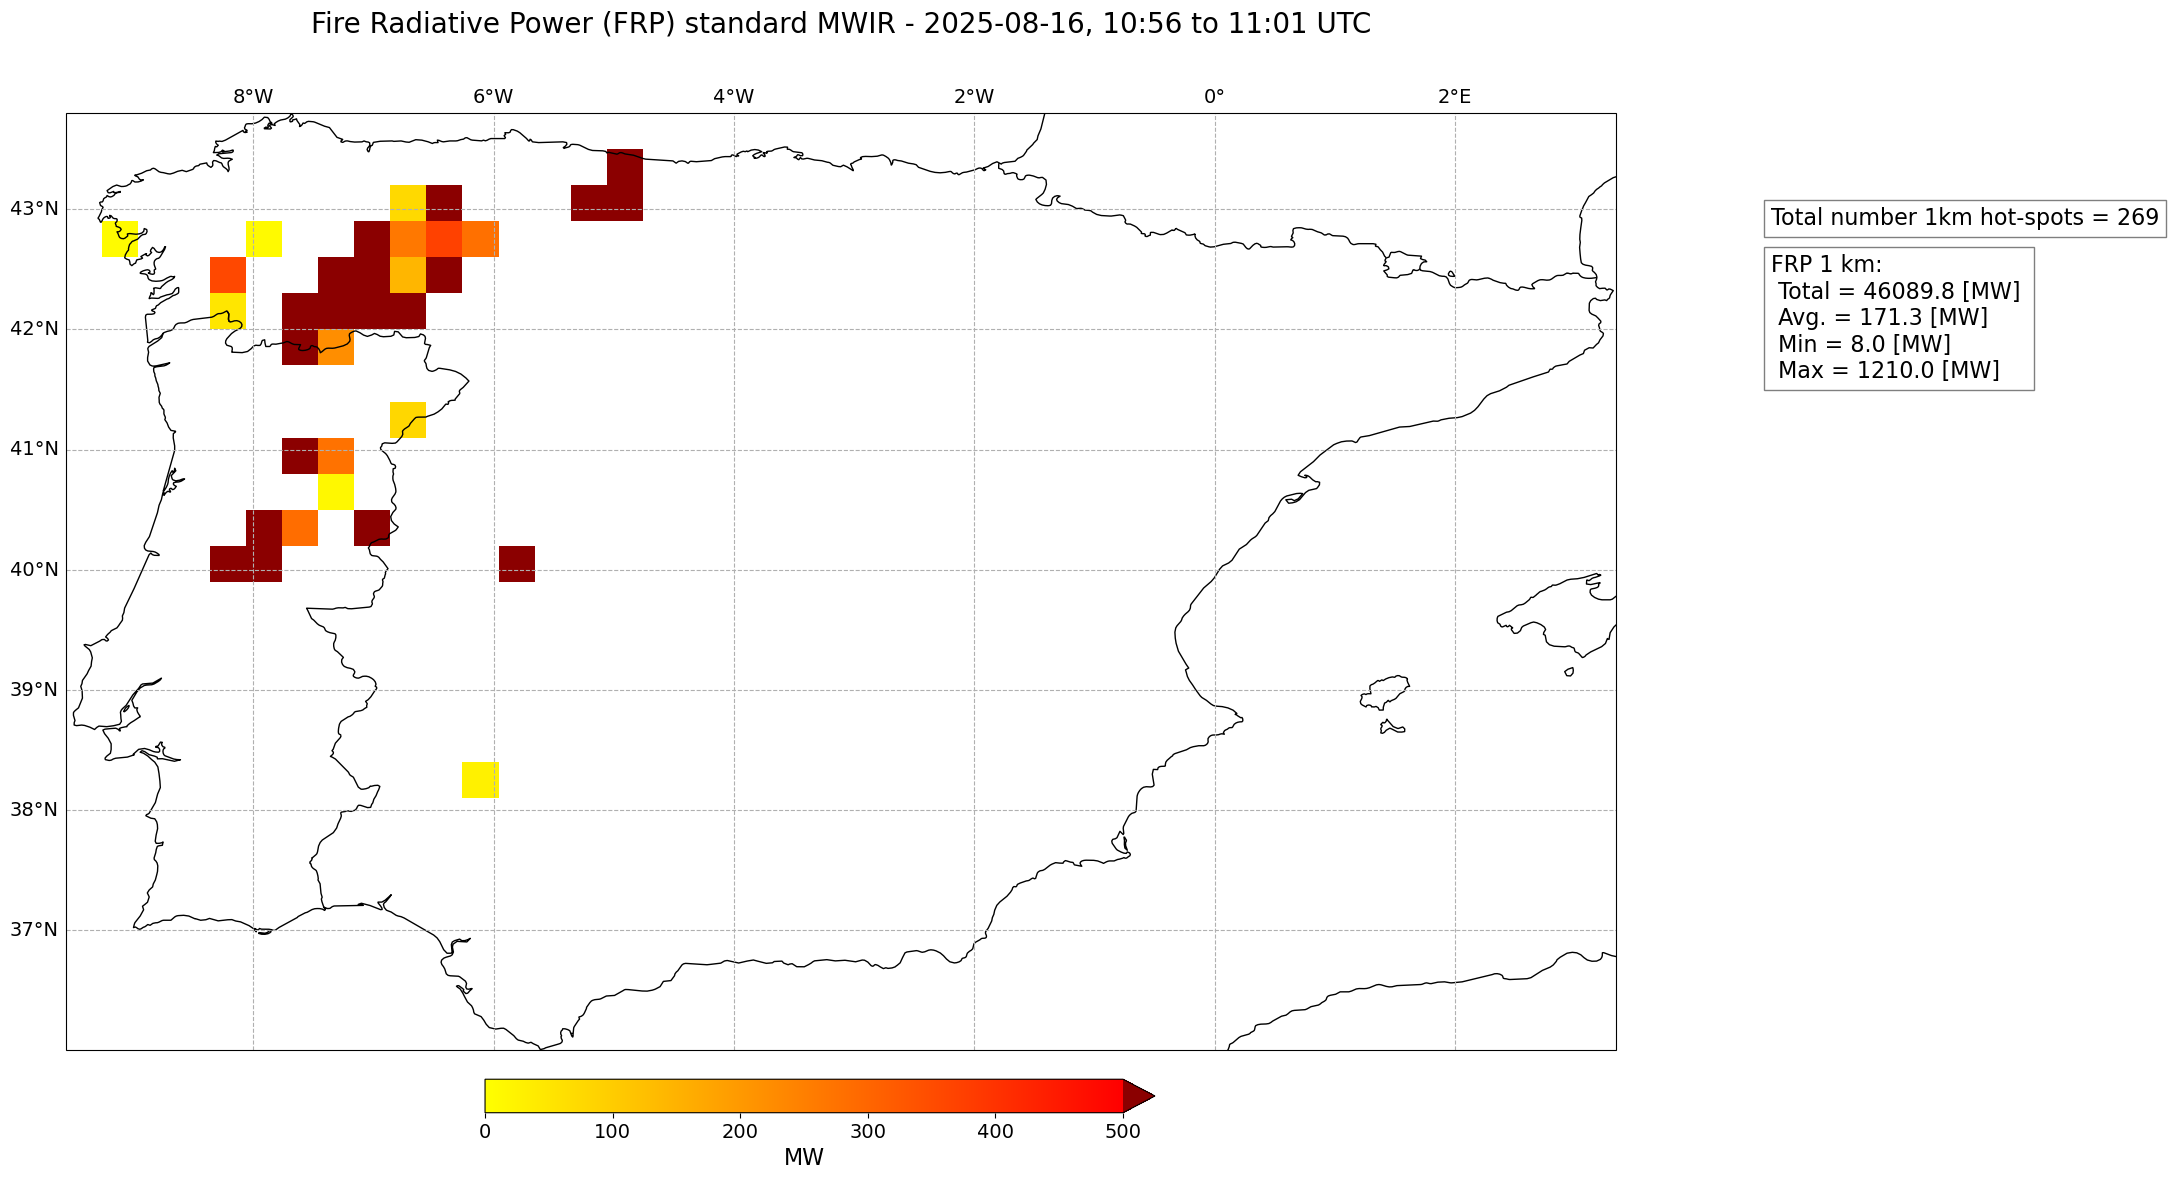

In [21]:
date = start_time[0:10]
start_time_hour = start_time[11:16]
stop_time_hour = stop_time[11:16]

long_name = f"Fire Radiative Power (FRP) standard MWIR - {date}, {start_time_hour} to {stop_time_hour} UTC"
unit = frp_mwir.units
vmax = FRP_plot_max_grid

frp_fig = visualize_s3_frp(data=D_mwir[:,:],
                 lat=lat_grid, 
                 lon=lon_grid, 
                 unit=unit, 
                 longname=long_name, 
                 textstr_1=textstr_1, 
                 textstr_2=textstr_2, 
                 vmax=FRP_plot_max_grid,
                 show=True)

### <a id='load_s3_AOD'></a>4.2 - Load Sentinel-3 SLSTR NRT AOD data

Each product is distributed as a **folder** ending with `.SEN3/`.  
Inside, multiple NetCDF files and metadata components are included.

- **`NRT_AOD.nc`** → Main aerosol product file, containing:
  - Geophysical variables such as:
    - `AOD_xxx` (e.g., 550, 670)
    - Ångström exponent: `ANG550_865`
    - Single Scattering Albedo: `SSA_xxx`(e.g., 550, 670)
    - Fine-mode and dust AOD (`FM_AOD550`, `D_AOD550`)
  - Geolocation: `latitude`, `longitude`, pixel corner coordinates
  - Quality information: `aod_quality_flags`
- **`xfdumanifest.xml`** → Manifest file describing metadata and file list.  

In practice, for this training we will use the **`NRT_AOD.nc`** file , which contains all the necessary variables (aerosol, geolocation, and quality).

The Near-Real-Time Sentinel-3 Aerosol Optical Depth data are disseminated in `netCDF`. `netCDF` data can be loaded with the Python library [xarray](http://xarray.pydata.org/en/stable/) and the function `xr.open_dataset()`. 

You see that the data file contains two `dimensions`:
* `columns` and
* `rows`.

It further contains an long list of `data variables`, including:
* `AOD_550`,
* `AOD_550_uncertainty`,
* `AOD_550_Ocean_NonFiltered`,
* `AOD_550_Land_Experimental_PostFiltered`,
...

A data file also contains a set of `attributes`, which give you more information about the data file and the data it contains, e.g the `start_time` and `stop_time` or the `product_name`.

In [22]:
data_folder = 'S3A_SL_2_AOD____20250816T105652_20250816T110152_20250816T130000_0299_129_208______MAR_O_NR_003.SEN3'
aod_xr = xr.open_dataset(Path(output_path) / data_folder / data_folder / "NRT_AOD.nc", engine='netcdf4')
aod_xr

<xarray.Dataset> Size: 8MB
Dimensions:                                (rows: 211, columns: 157)
Coordinates:
    longitude                              (rows, columns) float32 133kB ...
Dimensions without coordinates: rows, columns
Data variables: (12/57)
    AOD_550                                (rows, columns) float32 133kB ...
    AOD_550_Land                           (rows, columns) float32 133kB ...
    AOD_550_uncertainty                    (rows, columns) float32 133kB ...
    AOD_550_uncertainty_Land               (rows, columns) float32 133kB ...
    AOD_550_Merged_OceanLand               (rows, columns) float32 133kB ...
    AOD_670                                (rows, columns) float32 133kB ...
    ...                                     ...
    scattering_angle_oblique               (rows, columns) float32 133kB ...
    cloud_fraction_nadir                   (rows, columns) float32 133kB ...
    cloud_fraction_oblique                 (rows, columns) float32 133kB ...
    aod_quality_flags                      (rows, columns) uint16 66kB ...
    SLN_L1b_quality_flags                  (rows, columns) uint32 133kB ...
    SLO_L1b_quality_flags                  (rows, columns) uint32 133kB ...
Attributes: (12/17)
    title:                  Surface directional Reflectance, retrieved and de...
    comment:                 
    netCDF_version:         4.2 of Jun 13 2024 12:58:03 $
    product_name:           S3A_SL_2_AOD____20250816T105652_20250816T110152_2...
    institution:            MAR
    source:                 IPF-SL-2-AOD 04.02
    ...                     ...
    absolute_orbit_number:  49461
    start_time:             2025-08-16T10:56:52.225170Z
    stop_time:              2025-08-16T11:01:51.611398Z
    processing_baseline:    AOD_NRT.003.01.01
    track_offset:           105
    start_offset:           1462

First we will select the quality-assured  `AOD_550_Merged_OceanLand`, which is the Aerosol Optical Depth at 550nm, `latitude`, `longitude`, `start_time` and `stop_time`. 

`AOD_550_Merged_OceanLand` is the merged product covering all surfaces (land + ocean) and uses QI = 2 & 3 for water surfaces and QI = 3 for land. Provides a harmonized global AOD field for scientific analysis.

Both `xarray.DataArrays` have two dimensions (`rows` and `columns`) and the following attributes, which provide additional information about the variables:
* `long_name`
* `standard_name`
* `valid_min`
* `valid_max`
* `coordinates`

In [23]:
aod_merged = aod_xr.AOD_550_Merged_OceanLand
lat_nc = aod_xr.latitude
lon_nc = aod_xr.longitude
start_time = aod_xr.start_time
stop_time = aod_xr.stop_time

lon_nc

<xarray.DataArray 'longitude' (rows: 211, columns: 157)> Size: 133kB
[33127 values with dtype=float32]
Coordinates:
    longitude  (rows, columns) float32 133kB ...
Dimensions without coordinates: rows, columns
Attributes:
    long_name:      Longitude at pixel centre
    standard_name:  longitude
    units:          degrees_east
    valid_min:      -180.0
    valid_max:      180.0

Based on the quality-filtered scene (or swath), it is straightforward to calculate descriptive statistics using **Xarray** library for the AOD scene, such as the average, standard deviation, minimum, and maximum values.

In [24]:
aod_mean = aod_merged.mean().item()
aod_std = aod_merged.std().item()
aod_min = aod_merged.min().item()
aod_max =aod_merged.max().item()
print(f'Average = {aod_mean:.2f} ± {aod_std:.2f} - Min = {aod_min:.2f} - Max = {aod_max:.2f}')

Average = 0.49 ± 0.35 - Min = 0.00 - Max = 2.04


The map visualization including the quality filtered AOD scene is then executed by the auxiliary function `visualize_s3_aod`, as follows:

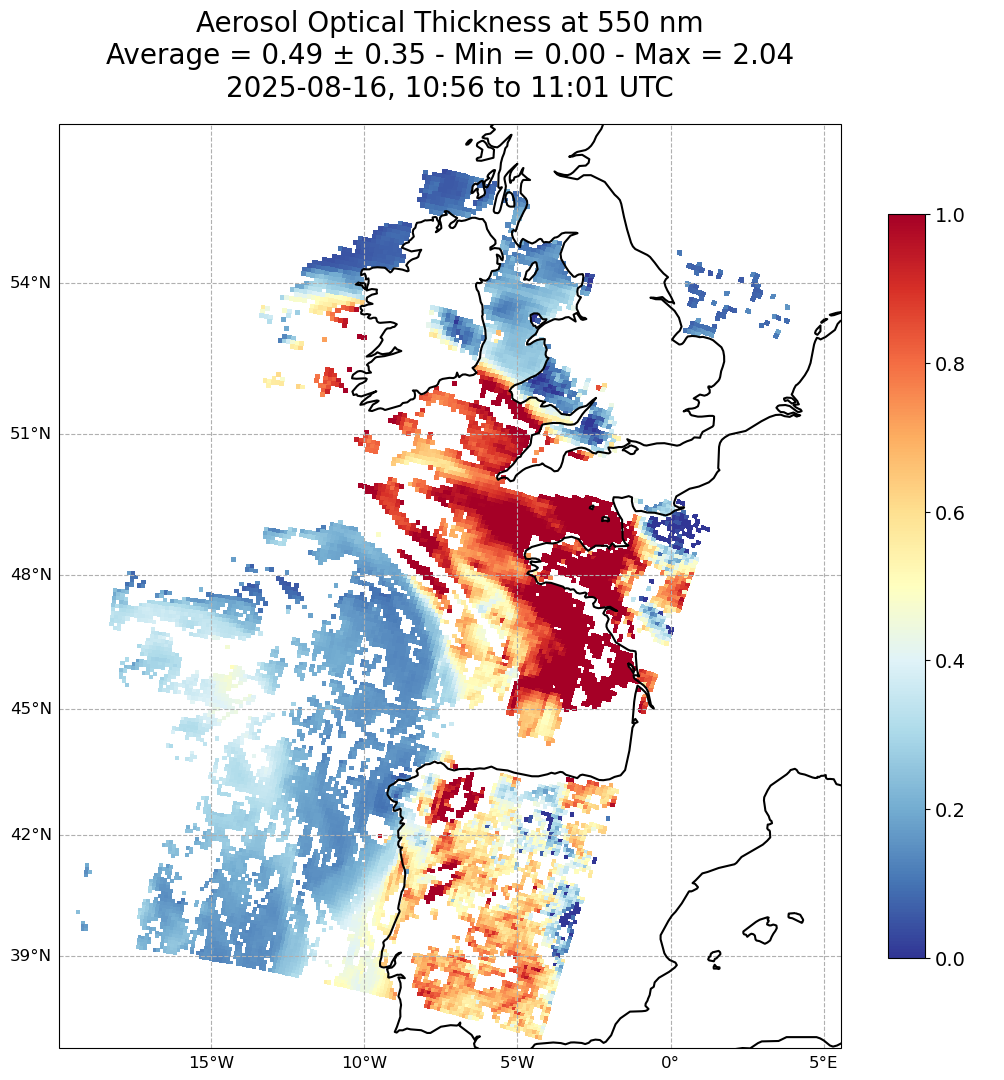

In [25]:
date = start_time[0:10]
start_time_hour = start_time[11:16]
stop_time_hour = stop_time[11:16]

aod_fig = visualize_s3_aod(aod_ocean=aod_merged, 
                 aod_land=aod_merged, 
                 latitude=lat_nc, 
                 longitude=lon_nc, 
                 title=f'Aerosol Optical Thickness at 550 nm\nAverage = {aod_mean:.2f} ± {aod_std:.2f} - Min = {aod_min:.2f} - Max = {aod_max:.2f}\n{date}, {start_time_hour} to {stop_time_hour} UTC', 
                 unit=' ', 
                 vmin=0.,
                 vmax=1.0,
                 color_scale=cm.RdYlBu_r,
                 projection=ccrs.Mercator(),
                 show=True)

We can then plot FRP and AOD side by side.

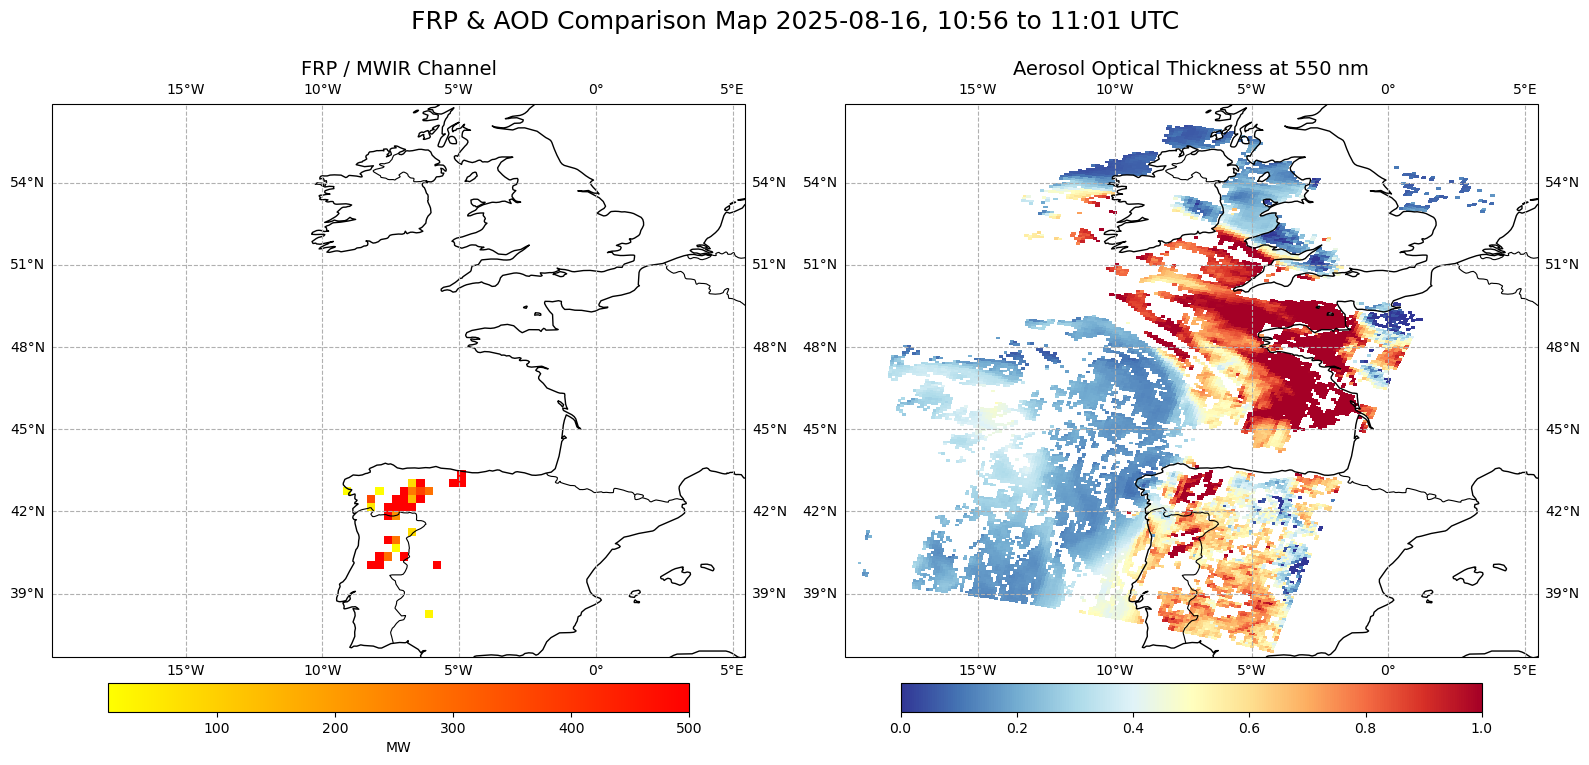

In [26]:
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 2, figsize=(16, 8),
    subplot_kw={'projection': proj},
    constrained_layout=False  # disable automatic layout since we will control it
)

fig.suptitle(f"FRP & AOD Comparison Map {date}, {start_time_hour} to {stop_time_hour} UTC", fontsize=18, y=0.95)

# FRP
axes[0].set_title("FRP / MWIR Channel", fontsize=14)
axes[0].coastlines()
axes[0].add_feature(cfeature.BORDERS, linewidth=0.8)
axes[0].gridlines(draw_labels=True, linestyle='--')

im1 = axes[0].pcolormesh(lon_grid, lat_grid, D_mwir,
                         transform=ccrs.PlateCarree(),
                         cmap='autumn_r', shading='auto',
                         vmax=FRP_plot_max_grid)
plt.colorbar(im1, ax=axes[0], orientation='horizontal',
             fraction=0.046, pad=0.04, label='MW')

# AOD
axes[1].set_title("Aerosol Optical Thickness at 550 nm", fontsize=14)
axes[1].coastlines()
axes[1].add_feature(cfeature.BORDERS, linewidth=0.8)
axes[1].gridlines(draw_labels=True, linestyle='--')

im2 = axes[1].pcolormesh(lon_nc, lat_nc, aod_merged,
                         transform=ccrs.PlateCarree(),
                         cmap='RdYlBu_r', shading='auto', vmin=0, vmax=1)
plt.colorbar(im2, ax=axes[1], orientation='horizontal',
             fraction=0.046, pad=0.04)

fig.tight_layout(rect=[0, 0, 1, 0.93])  # leave space at top for suptitle

extent_im2 = [lon_nc.min(), lon_nc.max(), lat_nc.min(), lat_nc.max()]
axes[0].set_extent(extent_im2, crs=ccrs.PlateCarree())
axes[1].set_extent(extent_im2, crs=ccrs.PlateCarree())

plt.show()


# 7. Conclusion

[Go back to the "Table of contents"](#Table-of-contents)

In this notebook, we explored the Iberian Peninsula wildfires from 15 to 17 August 2025 as a case study using Sentinel-3 satellite observations.

Using **Sentinel-3 Fire Radiative Power (FRP)** data, we identified active fire locations and quantified their intensity. FRP provides a near-real-time measure of the energy released by fires, which is directly related to combustion rate and biomass consumption.

In parallel, **Sentinel-3 Aerosol Optical Depth (AOD)** observations allowed us to assess the atmospheric impact of these fires. Elevated AOD values highlighted the presence and transport of smoke plumes, demonstrating how wildfire emissions can affect air quality locally and regionally.

By combining FRP and AOD products, we obtained a more comprehensive view of wildfire events - linking fire activity at the surface with atmospheric aerosol loading. This synergy illustrates the value of multi-product satellite analysis for disaster monitoring, air-quality assessment, and climate studies.

Overall, Sentinel-3 provides a powerful capability for monitoring both wildfire dynamics and their environmental impacts, supporting decision-makers and emergency management services in fire-prone regions such as Southern Europe.

<div class="alert alert-block alert-success">
    <b>Congratulations !!</b><br>
  
--- 

##### **And thank you for your attention! :)** 
    
    
We hope you enjoyed this Jupyter Notebook training.

Feel free to re-use and adapt all the Python scripts of this notebook to your needs! 

This training course is over but we'd love to hear from you about how we could improve it (topics, tools, storytelling, format, speed etc). If you have any question, do not hesitate to contact us using our [**live chat widget**](https://www.wekeo.eu/support) or asynchronously at [support@wekeo.eu](support@wekeo.eu) !


# Additional Information
---

#### Compatible Data Science Toolkits

In [7]:
import pkg_resources; pkg_resources.get_distribution("hda").version

'2.34'

In [8]:
import xarray; print(xarray.__version__)

2024.5.0


#### Last Modified and Tested

In [9]:
from datetime import date; print(date.today())

2026-02-17


<img src='https://github.com/wekeo/ai4EM_MOOC/raw/04147f290cfdcce341f819eab7ad037b95f25600/img/ai4eo_logos.jpg' alt='Logo EU Copernicus WEkEO' align='center' width='100%'></img>